In [1]:
import os
import random
import shutil
from pathlib import Path

import torch
import torch.nn as nn

import cv2
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.windows import Window
from torch.utils.data import ConcatDataset, DataLoader, Dataset
from tqdm import tqdm

import albumentations as A
import gradio as gr
import segmentation_models_pytorch as smp
from ultralytics import YOLO


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")


MODEL_NAME = "yolo11n-obb.pt"
REAL_CAR_LEN_M = 4.5
DEFAULT_SCALE_M_PER_PIXEL = 0.3

CROP_SIZE = 1024
TILE_SIZE = 512
STRIDE = 400
BATCH_SIZE = 8
NUM_EPOCHS = 5
LR = 1e-4


MODEL_WEIGHTS_PATH = (
    Path("weights")
    / "linknet_resnet34_buildings.pth"
)
MODEL_WEIGHTS_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)


def configure_dataset_paths(dataset_path: str | Path):
    dataset_path = Path(dataset_path)

    images_dir = dataset_path / "train" / "images"
    masks_dir = dataset_path / "train" / "gt"

    if not dataset_path.is_dir():
        raise FileNotFoundError(
            f"Не найдена папка датасета:\n{dataset_path.resolve()}"
        )

    if not images_dir.is_dir():
        raise FileNotFoundError(
            f"Не найдена папка изображений:\n{images_dir.resolve()}"
        )

    if not masks_dir.is_dir():
        raise FileNotFoundError(
            f"Не найдена папка масок:\n{masks_dir.resolve()}"
        )

    image_count = len(list(images_dir.glob("*.tif")))
    mask_count = len(list(masks_dir.glob("*.tif")))

    if image_count == 0:
        raise RuntimeError(
            f"В папке нет .tif изображений:\n{images_dir.resolve()}"
        )

    if mask_count == 0:
        raise RuntimeError(
            f"В папке нет .tif масок:\n{masks_dir.resolve()}"
        )

    print(f"Рабочая папка:   {Path.cwd()}")
    print(f"Корень датасета: {dataset_path.resolve()}")
    print(f"Изображения:     {images_dir.resolve()}")
    print(f"Маски:           {masks_dir.resolve()}")
    print(f"Изображений:     {image_count}")
    print(f"Масок:           {mask_count}")
    print(f"Путь весов:      {MODEL_WEIGHTS_PATH.resolve()}")

    return dataset_path, images_dir, masks_dir

Device: cuda


## Блок для скачивания датасета

In [ ]:
import kagglehub

DATASET_DOWNLOAD_PATH = Path(
    kagglehub.dataset_download(
        "sagar100rathod/inria-aerial-image-labeling-dataset"
    )
)

dataset_candidate = (
    DATASET_DOWNLOAD_PATH
    / "AerialImageDataset"
)

if not dataset_candidate.is_dir():
    candidates = [
        path
        for path in DATASET_DOWNLOAD_PATH.rglob(
            "AerialImageDataset"
        )
        if path.is_dir()
    ]

    if not candidates:
        raise FileNotFoundError(
            "Папка AerialImageDataset не найдена внутри:\n"
            f"{DATASET_DOWNLOAD_PATH}"
        )

    dataset_candidate = candidates[0]

DATASET_PATH, IMAGES_DIR, MASKS_DIR = (
    configure_dataset_paths(dataset_candidate)
)

##  Блок при наличии датасета в нужной директории

In [2]:

EXISTING_DATASET_PATH = (
    Path(".cache")
    / "kagglehub"
    / "datasets"
    / "sagar100rathod"
    / "inria-aerial-image-labeling-dataset"
    / "versions"
    / "1"
    / "AerialImageDataset"
)

DATASET_PATH, IMAGES_DIR, MASKS_DIR = (
    configure_dataset_paths(
        EXISTING_DATASET_PATH
    )
)

Рабочая папка:   C:\Users\bob32
Корень датасета: C:\Users\bob32\.cache\kagglehub\datasets\sagar100rathod\inria-aerial-image-labeling-dataset\versions\1\AerialImageDataset
Изображения:     C:\Users\bob32\.cache\kagglehub\datasets\sagar100rathod\inria-aerial-image-labeling-dataset\versions\1\AerialImageDataset\train\images
Маски:           C:\Users\bob32\.cache\kagglehub\datasets\sagar100rathod\inria-aerial-image-labeling-dataset\versions\1\AerialImageDataset\train\gt
Изображений:     180
Масок:           180
Путь весов:      C:\Users\bob32\weights\linknet_resnet34_buildings.pth


In [3]:
def normalize_rgb(img: np.ndarray) -> np.ndarray:
    img = np.asarray(img)
    if img.max() > 255:
        img = (img / (img.max() / 255)).astype(np.uint8)
    else:
        img = img.astype(np.uint8)
    return img


def get_tile_coords(width: int, height: int, tile_size: int, stride: int) -> list[tuple[int, int]]:
    if width < tile_size or height < tile_size:
        raise ValueError("Изображение меньше размера тайла. Уменьшите TILE_SIZE.")

    xs = list(range(0, width - tile_size + 1, stride))
    ys = list(range(0, height - tile_size + 1, stride))

    if xs[-1] != width - tile_size:
        xs.append(width - tile_size)
    if ys[-1] != height - tile_size:
        ys.append(height - tile_size)

    return [(x, y) for y in ys for x in xs]


def read_rgb_window(src: rasterio.io.DatasetReader, window: Window | None = None) -> np.ndarray:
    img = src.read([1, 2, 3], window=window)
    return np.transpose(img, (1, 2, 0))

## Оценка масштаба изображения


In [4]:
def process_aerial_scale(
    tif_path: str | Path,
    model_name: str = MODEL_NAME,
    crop_size: int = CROP_SIZE,
    real_car_len_m: float = REAL_CAR_LEN_M,
    default_scale: float = DEFAULT_SCALE_M_PER_PIXEL,
) -> float:
    model_yolo = YOLO(model_name)

    with rasterio.open(tif_path) as src:
        cx, cy = src.width // 2, src.height // 2
        left = max(0, cx - crop_size // 2)
        top = max(0, cy - crop_size // 2)
        width = min(crop_size, src.width - left)
        height = min(crop_size, src.height - top)
        window = Window(left, top, width, height)
        img = normalize_rgb(read_rgb_window(src, window))

    results = model_yolo.predict(img, conf=0.3, imgsz=crop_size, device=DEVICE, verbose=False)
    obb = getattr(results[0], "obb", None)

    if obb is None or obb.xywhr is None or len(obb.xywhr) == 0:
        print(f"Машины не найдены. Используется масштаб по умолчанию: {default_scale} м/пиксель")
        return default_scale

    wh = obb.xywhr[:, 2:4].cpu().numpy()
    pixel_lengths = np.max(wh, axis=1)
    pixel_lengths = pixel_lengths[(pixel_lengths > 10) & (pixel_lengths < 150)]

    if len(pixel_lengths) == 0:
        print(f"Подходящие машины не найдены. Используется масштаб по умолчанию: {default_scale} м/пиксель")
        return default_scale

    avg_px_len = float(np.mean(pixel_lengths))
    scale = real_car_len_m / avg_px_len
    print(f"Расчетный масштаб: {scale:.4f} м/пиксель")
    return scale

In [5]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
])


class InriaSlidingWindowDataset(Dataset):
    def __init__(
        self,
        img_path: str | Path,
        mask_path: str | Path | None = None,
        tile_size: int = TILE_SIZE,
        stride: int = STRIDE,
        transform: A.Compose | None = None,
    ):
        self.img_path = Path(img_path)
        self.mask_path = Path(mask_path) if mask_path is not None else None
        self.tile_size = tile_size
        self.transform = transform

        with rasterio.open(self.img_path) as src:
            self.height, self.width = src.height, src.width

        self.coords = get_tile_coords(self.width, self.height, tile_size, stride)

    def __len__(self) -> int:
        return len(self.coords)

    def __getitem__(self, idx: int):
        x, y = self.coords[idx]
        window = Window(x, y, self.tile_size, self.tile_size)

        with rasterio.open(self.img_path) as src:
            img = read_rgb_window(src, window)

        if self.mask_path is not None:
            with rasterio.open(self.mask_path) as mask_src:
                mask = mask_src.read(1, window=window)
            mask = (mask > 0).astype(np.float32)
        else:
            mask = np.zeros((self.tile_size, self.tile_size), dtype=np.float32)

        if self.transform is not None:
            augmented = self.transform(image=img, mask=mask)
            img, mask = augmented["image"], augmented["mask"]

        img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        mask = torch.from_numpy(mask).unsqueeze(0).float()
        return img, mask


def setup_data(
    img_dir: str | Path = IMAGES_DIR,
    mask_dir: str | Path = MASKS_DIR,
    split_ratio: float = 0.8,
    batch_size: int = BATCH_SIZE,
):
    img_dir = Path(img_dir)
    mask_dir = Path(mask_dir)

    all_files = sorted([f.name for f in img_dir.glob("*.tif")])
    random.Random(SEED).shuffle(all_files)

    split_idx = int(len(all_files) * split_ratio)
    train_files = all_files[:split_idx]
    val_files = all_files[split_idx:]

    train_datasets = [
        InriaSlidingWindowDataset(img_dir / name, mask_dir / name, transform=train_transform)
        for name in train_files
    ]
    val_datasets = [
        InriaSlidingWindowDataset(img_dir / name, mask_dir / name, transform=None)
        for name in val_files
    ]

    train_loader = DataLoader(
        ConcatDataset(train_datasets),
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
    )
    val_loader = DataLoader(
        ConcatDataset(val_datasets),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )

    return train_loader, val_loader, train_files, val_files

In [6]:
class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = smp.losses.DiceLoss(
            mode="binary",
            from_logits=True,
        )

    def forward(self, logits, targets):
        return 0.5 * self.bce(logits, targets) + 0.5 * self.dice(logits, targets)


def build_model() -> nn.Module:
    return smp.Linknet(
        encoder_name="resnet34",
        encoder_weights="imagenet",
        classes=1,
        activation=None,
    )


def segmentation_metrics(logits, targets, threshold: float = 0.5, eps: float = 1e-7) -> dict[str, float]:
    probabilities = torch.sigmoid(logits)
    preds = (probabilities > threshold).float()
    targets = (targets > 0.5).float()

    tp = (preds * targets).sum()
    fp = (preds * (1 - targets)).sum()
    fn = ((1 - preds) * targets).sum()

    iou = tp / (tp + fp + fn + eps)
    dice = (2 * tp) / (2 * tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)

    return {
        "iou": float(iou.item()),
        "dice": float(dice.item()),
        "precision": float(precision.item()),
        "recall": float(recall.item()),
    }


In [7]:
def validate(model, loader, criterion, device: str = DEVICE) -> dict[str, float]:
    model.eval()
    total_loss = 0.0
    metric_sums = {"iou": 0.0, "dice": 0.0, "precision": 0.0, "recall": 0.0}
    n_batches = 0

    amp_device = "cuda" if str(device).startswith("cuda") else "cpu"
    use_amp = amp_device == "cuda"

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Validation"):
            images = images.to(device)
            masks = masks.to(device)

            with torch.amp.autocast(
                device_type=amp_device,
                dtype=torch.float16,
                enabled=use_amp,
            ):
                outputs = model(images)
                loss = criterion(outputs, masks)

            total_loss += loss.item()
            metrics = segmentation_metrics(outputs, masks)
            for key in metric_sums:
                metric_sums[key] += metrics[key]
            n_batches += 1

    result = {key: value / max(n_batches, 1) for key, value in metric_sums.items()}
    result["loss"] = total_loss / max(n_batches, 1)
    return result


def train(model, train_loader, val_loader, optimizer, criterion, epochs: int = NUM_EPOCHS, device: str = DEVICE):
    model.to(device)
    history = []

    amp_device = "cuda" if str(device).startswith("cuda") else "cpu"
    use_amp = amp_device == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs}")
        for images, masks in pbar:
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()

            with torch.amp.autocast(
                device_type=amp_device,
                dtype=torch.float16,
                enabled=use_amp,
            ):
                outputs = model(images)
                loss = criterion(outputs, masks)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        train_loss = total_loss / max(len(train_loader), 1)
        val_metrics = validate(model, val_loader, criterion, device)

        epoch_info = {"epoch": epoch + 1, "train_loss": train_loss, **val_metrics}
        history.append(epoch_info)

        print(
            f"Epoch {epoch + 1}: "
            f"train_loss={train_loss:.4f}, "
            f"val_loss={val_metrics['loss']:.4f}, "
            f"IoU={val_metrics['iou']:.4f}, "
            f"Dice={val_metrics['dice']:.4f}"
        )

    return history


### блок с обучение и сохранение весов

In [ ]:
train_loader, val_loader, train_filenames, val_filenames = setup_data()

model = build_model().to(DEVICE)
criterion = BCEDiceLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
)

history = train(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs=NUM_EPOCHS,
)

torch.save(
    model.state_dict(),
    MODEL_WEIGHTS_PATH,
)

model.eval()

print(
    f"Weights saved to: "
    f"{MODEL_WEIGHTS_PATH.resolve()}"
)

### блок при наличии сохранённых весов

In [8]:
if not MODEL_WEIGHTS_PATH.is_file():
    raise FileNotFoundError(
        "Файл сохранённых весов не найден:\n"
        f"{MODEL_WEIGHTS_PATH.resolve()}\n\n"
        "Сначала запусти вариант с обучением модели."
    )

model = build_model().to(DEVICE)

state_dict = torch.load(
    MODEL_WEIGHTS_PATH,
    map_location=DEVICE,
    weights_only=True,
)

model.load_state_dict(state_dict)
model.eval()

print(
    "Weights loaded from: "
    f"{MODEL_WEIGHTS_PATH.resolve()}"
)

Weights loaded from: C:\Users\bob32\weights\linknet_resnet34_buildings.pth


In [9]:
def predict_and_stitch(
    model: nn.Module,
    tif_path: str | Path,
    scale_m_per_pixel: float,
    tile_size: int = TILE_SIZE,
    stride: int = STRIDE,
    batch_size: int = BATCH_SIZE,
    device: str = DEVICE,
):
    model.eval()

    with rasterio.open(tif_path) as src:
        height, width = src.height, src.width

    full_mask = np.zeros((height, width), dtype=np.float32)
    count_map = np.zeros((height, width), dtype=np.float32)

    dataset = InriaSlidingWindowDataset(tif_path, tile_size=tile_size, stride=stride)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    idx = 0
    with torch.no_grad():
        for images, _ in tqdm(loader, desc="Inference"):
            images = images.to(device)
            logits = model(images)
            preds = torch.sigmoid(logits).cpu().numpy()

            for i in range(preds.shape[0]):
                x, y = dataset.coords[idx]
                full_mask[y:y + tile_size, x:x + tile_size] += preds[i, 0]
                count_map[y:y + tile_size, x:x + tile_size] += 1.0
                idx += 1

    final_mask = (full_mask / np.maximum(count_map, 1) > 0.5).astype(np.uint8)
    area_m2 = float(final_mask.sum() * (scale_m_per_pixel ** 2))
    return final_mask, area_m2


def visualize_result(tif_path: str | Path, pred_mask: np.ndarray):
    with rasterio.open(tif_path) as src:
        img = normalize_rgb(read_rgb_window(src))

    overlay = np.zeros_like(img)
    overlay[pred_mask == 1] = [255, 0, 0]
    blended = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)

    fig = plt.figure(figsize=(12, 12))
    plt.imshow(blended)
    plt.title("Результат сегментации зданий")
    plt.axis("off")
    plt.tight_layout()
    return fig

In [10]:
def compare_with_gt(
    tif_path: str | Path,
    pred_mask: np.ndarray,
    scale_m_per_pixel: float,
    num_crops: int = 3,
    crop_size: int = 1024,
):
    tif_path = Path(tif_path)
    gt_path = Path(str(tif_path).replace("/images/", "/gt/"))

    with rasterio.open(tif_path) as src:
        original_img = normalize_rgb(read_rgb_window(src))
        height, width = src.height, src.width

    with rasterio.open(gt_path) as src:
        gt_mask = (src.read(1) > 0).astype(np.uint8)

    pred_binary = (pred_mask > 0).astype(np.uint8)
    intersection = np.logical_and(pred_binary, gt_mask).sum()
    union = np.logical_or(pred_binary, gt_mask).sum()

    iou = intersection / max(union, 1)
    dice = 2 * intersection / max(pred_binary.sum() + gt_mask.sum(), 1)

    area_gt = float(gt_mask.sum() * (scale_m_per_pixel ** 2))
    area_pred = float(pred_binary.sum() * (scale_m_per_pixel ** 2))
    area_error = area_pred - area_gt
    relative_area_error = area_error / max(area_gt, 1) * 100

    print(f"Файл: {tif_path.name}")
    print(f"IoU: {iou:.4f}")
    print(f"Dice: {dice:.4f}")
    print(f"Площадь GT: {area_gt:,.1f} м²")
    print(f"Площадь Pred: {area_pred:,.1f} м²")
    print(f"Ошибка площади: {area_error:+,.1f} м² ({relative_area_error:+.2f}%)")

    overlay = np.zeros_like(original_img)
    overlay[(pred_binary == 1) & (gt_mask == 1)] = [0, 255, 0]
    overlay[(pred_binary == 1) & (gt_mask == 0)] = [255, 0, 0]
    overlay[(pred_binary == 0) & (gt_mask == 1)] = [0, 0, 255]
    blended = cv2.addWeighted(original_img, 0.7, overlay, 0.3, 0)

    fig, axes = plt.subplots(num_crops, 1, figsize=(10, num_crops * 8))
    if num_crops == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        y = random.randint(0, max(height - crop_size, 0))
        x = random.randint(0, max(width - crop_size, 0))
        crop = blended[y:y + crop_size, x:x + crop_size]
        ax.imshow(crop)
        ax.set_title(f"Кроп {i + 1}: зеленый=TP, красный=FP, синий=FN")
        ax.axis("off")

    plt.tight_layout()
    return fig

## 11. Пример инференса

In [13]:
from pathlib import Path

import cv2
import numpy as np
import rasterio


# Папка для результатов.
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Путь к итоговому JPEG.
JPEG_PATH = RESULTS_DIR / f"{Path(tif_file).stem}_segmented.jpg"


# Загружаем исходное TIFF-изображение.
with rasterio.open(tif_file) as src:
    if src.count >= 3:
        image = src.read([1, 2, 3])
        image = np.transpose(image, (1, 2, 0))
    else:
        image = src.read(1)
        image = np.stack([image, image, image], axis=-1)


# Приводим изображение к uint8 для сохранения в JPEG.
if image.dtype != np.uint8:
    image = image.astype(np.float32)

    low = np.percentile(image, 2)
    high = np.percentile(image, 98)

    image = np.clip(
        (image - low) / max(high - low, 1e-7),
        0,
        1,
    )

    image = (image * 255).astype(np.uint8)


# Подготавливаем маску.
mask = np.asarray(pred_mask).squeeze()

# Если размеры маски и изображения различаются.
if mask.shape != image.shape[:2]:
    mask = cv2.resize(
        mask.astype(np.float32),
        (image.shape[1], image.shape[0]),
        interpolation=cv2.INTER_NEAREST,
    )

# Поддерживаются как вероятности 0–1, так и готовая бинарная маска.
if np.issubdtype(mask.dtype, np.floating):
    binary_mask = mask >= 0.5
else:
    binary_mask = mask > 0


# Создаём красное наложение.
segmented_image = image.copy()
red_color = np.array([255, 0, 0], dtype=np.float32)
alpha = 0.45

segmented_image[binary_mask] = (
    (1 - alpha) * segmented_image[binary_mask].astype(np.float32)
    + alpha * red_color
).astype(np.uint8)


# OpenCV сохраняет в BGR, поэтому преобразуем RGB → BGR.
success = cv2.imwrite(
    str(JPEG_PATH),
    cv2.cvtColor(segmented_image, cv2.COLOR_RGB2BGR),
    [cv2.IMWRITE_JPEG_QUALITY, 95],
)

if not success:
    raise RuntimeError(
        f"Не удалось сохранить изображение: {JPEG_PATH.resolve()}"
    )

print(f"Сегментированная карта сохранена:\n{JPEG_PATH.resolve()}")

Сегментированная карта сохранена:
C:\Users\bob32\results\austin31_segmented.jpg


Расчетный масштаб: 0.2839 м/пиксель


Inference: 100%|███████████████████████████████████████████████████████████████████████| 22/22 [00:03<00:00,  6.32it/s]


Площадь застройки: 157,044.92 м²


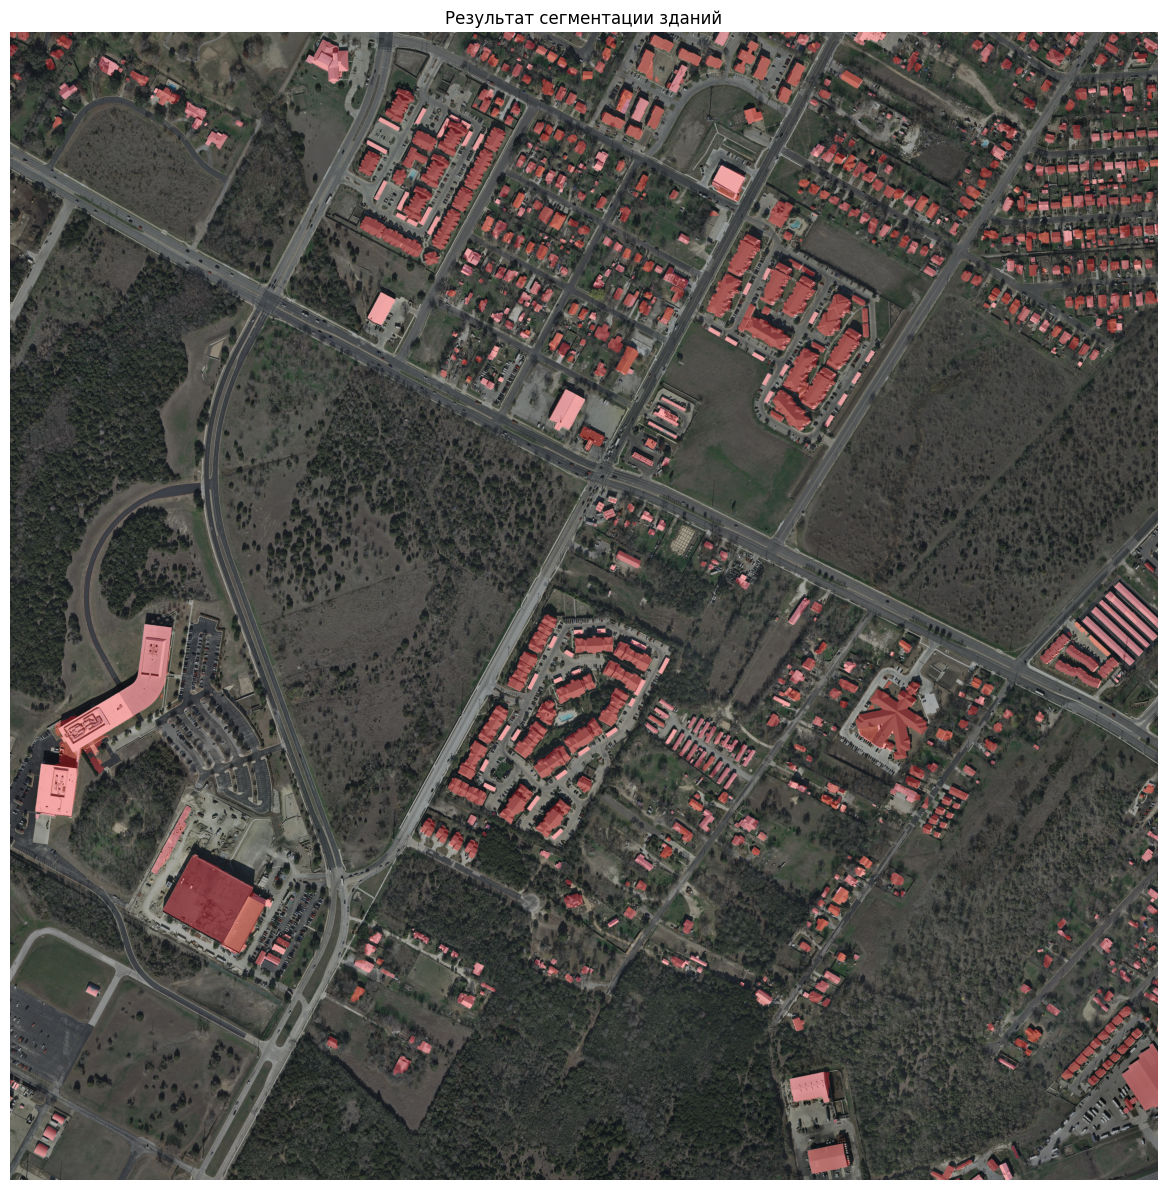

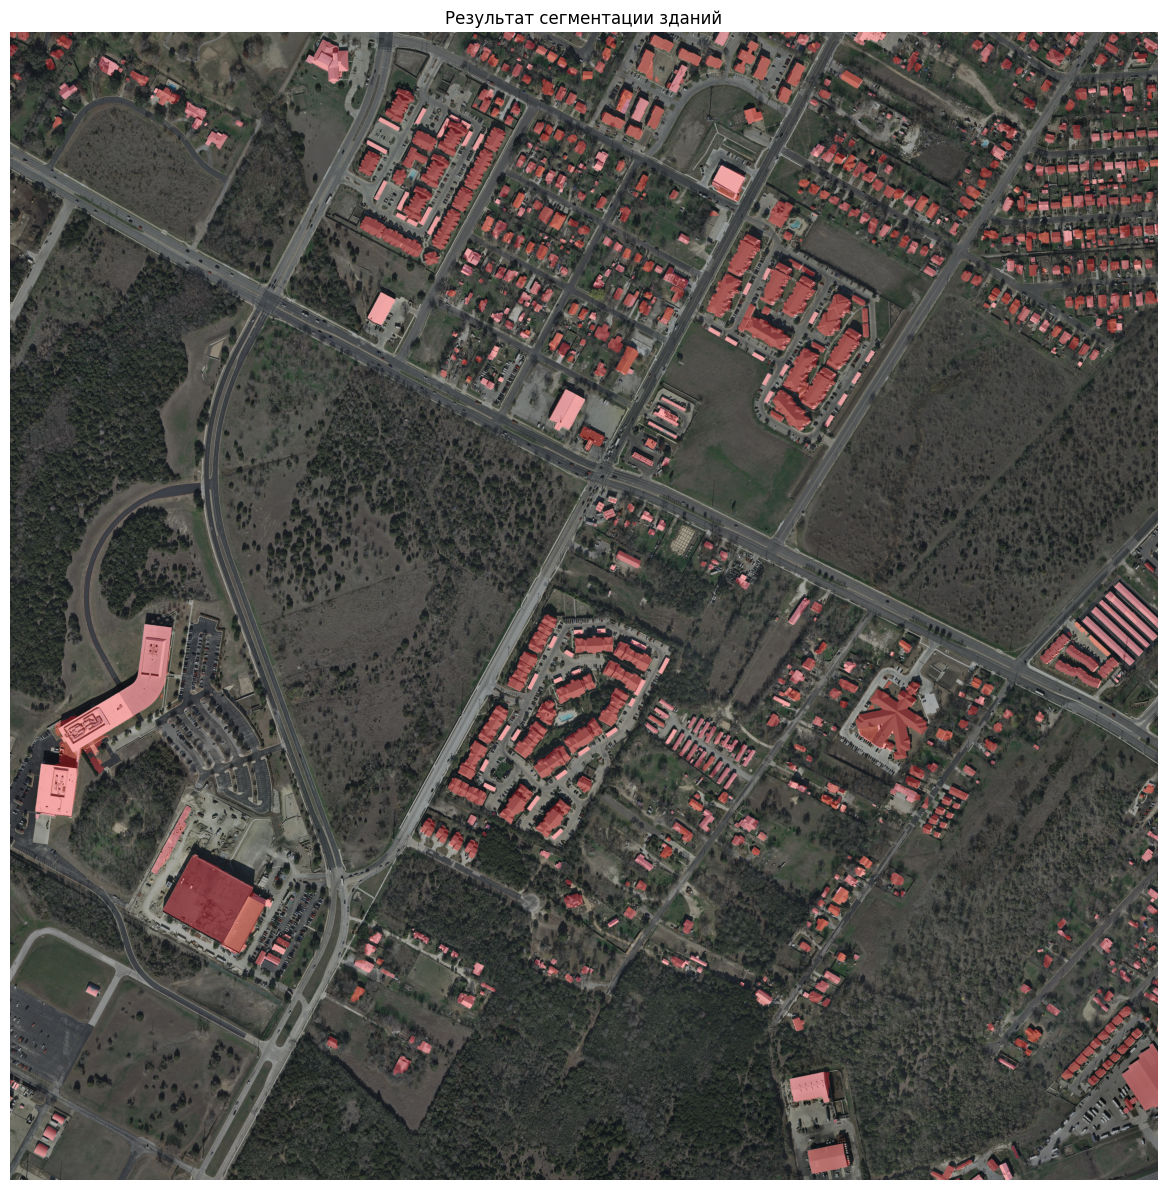

In [11]:
if "model" not in globals():
    raise RuntimeError(
        "Модель не инициализирована. "
        "Сначала запусти блок обучения "
        "или блок загрузки сохранённых весов."
    )

tif_file = IMAGES_DIR / "austin31.tif"

if not tif_file.is_file():
    raise FileNotFoundError(
        f"Не найден тестовый снимок: {tif_file.resolve()}"
    )

model.eval()

scale = process_aerial_scale(tif_file)
pred_mask, area_m2 = predict_and_stitch(
    model,
    tif_file,
    scale,
)

print(
    f"Площадь застройки: "
    f"{area_m2:,.2f} м²"
)

visualize_result(
    tif_file,
    pred_mask,
)

In [12]:
def process_image(img_path):
    try:
        scale = process_aerial_scale(img_path)
        mask, area = predict_and_stitch(model, img_path, scale)
        fig = visualize_result(img_path, mask)

        report = (
            "### Отчет анализа\n"
            f"- **Масштаб:** `{scale:.4f}` м/пиксель\n"
            f"- **Площадь застройки:** `{area:,.2f}` м²"
        )
        return fig, report
    except Exception as exc:
        return None, f"Ошибка: {exc}"


with gr.Blocks() as demo:
    gr.Markdown("# Анализ спутниковых снимков")

    with gr.Row():
        with gr.Column():
            input_img = gr.Image(type="filepath", label="Загрузите TIF")
            btn = gr.Button("Запустить", variant="primary")
        with gr.Column():
            plot_out = gr.Plot(label="Карта сегментации")
            text_out = gr.Markdown("Результаты появятся здесь")

    btn.click(process_image, inputs=input_img, outputs=[plot_out, text_out])

demo.launch(theme=gr.themes.Soft())

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


## Комментарий по результатам

Из-за ограничений видеопамяти используется LinkNet с `resnet34`, а не более тяжелая U-Net. Качество стоит подтверждать не только визуально и не только ошибкой площади, а метриками сегментации: IoU, Dice, Precision и Recall. Проблемы ожидаемы на монохромных объектах, парковках, лесах и зданиях необычной формы. Для улучшения можно увеличить число эпох, расширить аугментации и использовать более сильный encoder при наличии GPU-памяти.